# Marketing Campaign A/B Testing

## End-to-End Statistics & Analytics Project

This notebook is designed to satisfy the DMV Core Tech project requirements.

### Sections
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Summary Statistics
6. Distribution Comparison
7. Visualizations
8. Hypothesis Testing
9. Confidence Intervals
10. Effect Size (Cohen's d)
11. Power Analysis
12. Business Report & Recommendations


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.stats.power import TTestIndPower

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)


## Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("marketing_AB.csv")
df.head()

Saving marketing_AB.csv to marketing_AB (1).csv


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Data Cleaning

In [ ]:
df.columns=["Index","User_ID","Campaign","Converted",
              "Total_Ads","Most_Ads_Day","Most_Ads_Hour"]

df["Converted"]=df["Converted"].astype(int)

print(df.info())
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Index          588101 non-null  int64 
 1   User_ID        588101 non-null  int64 
 2   Campaign       588101 non-null  object
 3   Converted      588101 non-null  int64 
 4   Total_Ads      588101 non-null  int64 
 5   Most_Ads_Day   588101 non-null  object
 6   Most_Ads_Hour  588101 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 31.4+ MB
None
Index            0
User_ID          0
Campaign         0
Converted        0
Total_Ads        0
Most_Ads_Day     0
Most_Ads_Hour    0
dtype: int64
Duplicates: 0


,Index,User_ID,Campaign,Converted,Total_Ads,Most_Ads_Day,Most_Ads_Hour
0,0,1069124,ad,0,130,Monday,20
1,1,1119715,ad,0,93,Tuesday,22
2,2,1144181,ad,0,21,Tuesday,18
3,3,1435133,ad,0,355,Tuesday,10
4,4,1015700,ad,0,276,Friday,14


## Exploratory Analysis

In [ ]:
display(df.describe())
display(df.describe(include='object'))

display(df.groupby("Campaign").agg({
    "Converted":["count","sum","mean"],
    "Total_Ads":["mean","median","std","min","max"]
}))

,Index,User_ID,Converted,Total_Ads,Most_Ads_Hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,0.025239,24.820876,14.469061
std,169770.279667,2.022260e+05,0.156850,43.715181,4.834634
min,0.000000,9.000000e+05,0.000000,1.000000,0.000000
25%,147025.000000,1.143190e+06,0.000000,4.000000,11.000000
50%,294050.000000,1.313725e+06,0.000000,13.000000,14.000000
75%,441075.000000,1.484088e+06,0.000000,27.000000,18.000000
max,588100.000000,1.654483e+06,1.000000,2065.000000,23.000000


,Campaign,Most_Ads_Day
count,588101,588101
unique,2,7
top,ad,Friday
freq,564577,92608


Converted                   Total_Ads                            
             count    sum      mean       mean median        std min   max
Campaign                                                                  
ad          564577  14423  0.025547  24.823365   13.0  43.750456   1  2065
psa          23524    420  0.017854  24.761138   12.0  42.860720   1   907

## Visualizations

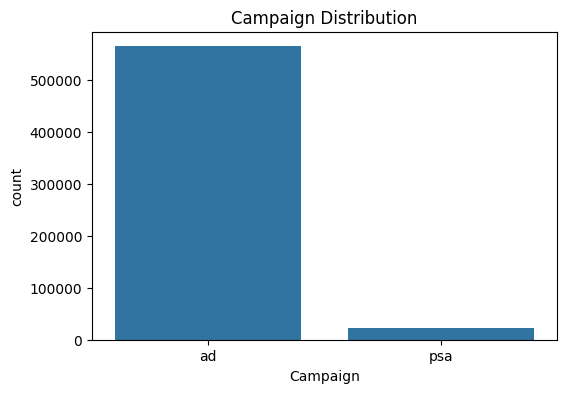

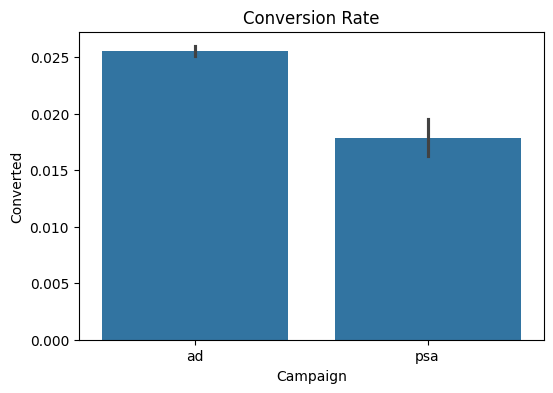

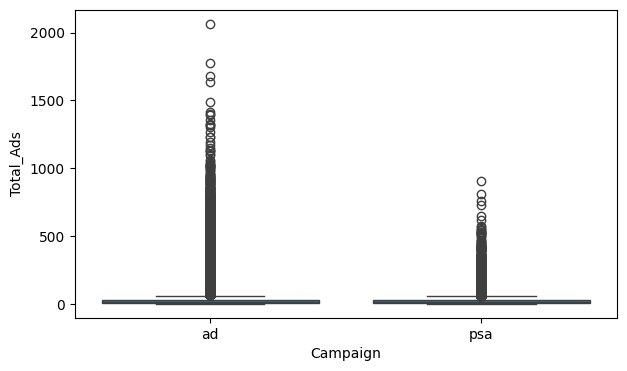

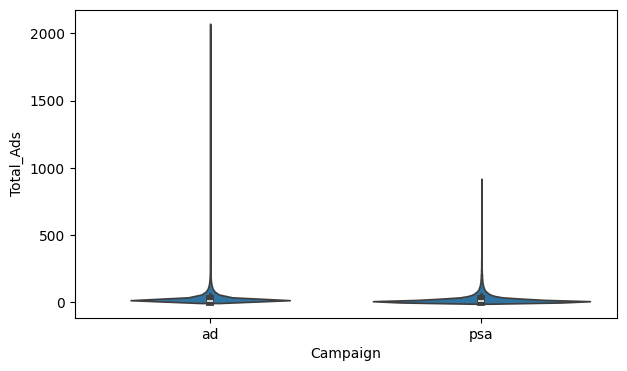

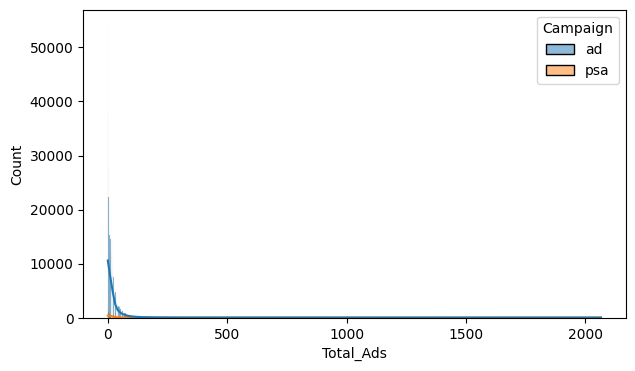

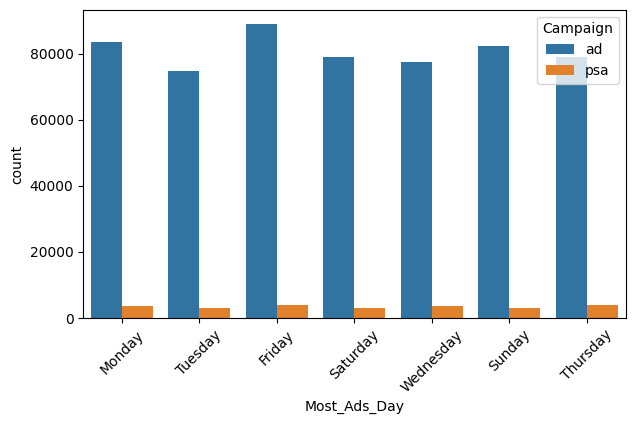

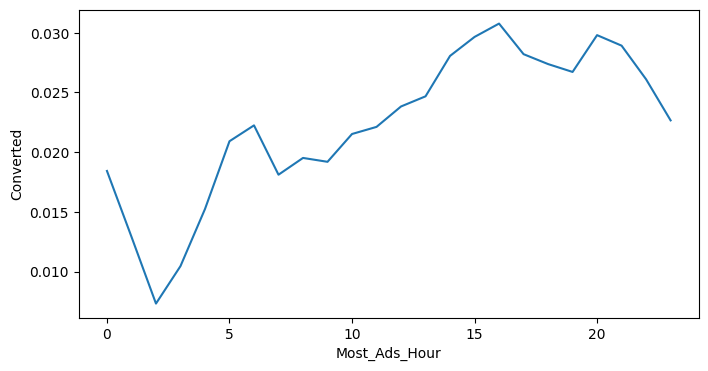

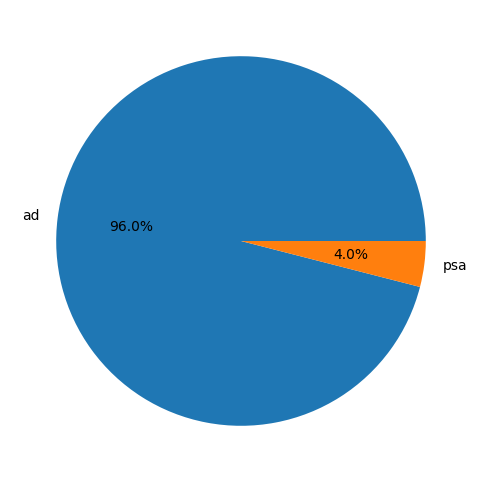

In [ ]:

plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Campaign")
plt.title("Campaign Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Campaign",y="Converted",estimator=np.mean)
plt.title("Conversion Rate")
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=df,x="Campaign",y="Total_Ads")
plt.show()

plt.figure(figsize=(7,4))
sns.violinplot(data=df,x="Campaign",y="Total_Ads")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(data=df,x="Total_Ads",hue="Campaign",kde=True)
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df,x="Most_Ads_Day",hue="Campaign")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,4))
sns.lineplot(data=df.groupby("Most_Ads_Hour")["Converted"].mean().reset_index(),
             x="Most_Ads_Hour",y="Converted")
plt.show()

plt.figure(figsize=(6,6))
df["Campaign"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.show()


## Hypothesis Testing

In [ ]:
campaign_a=df[df["Campaign"]=="ad"]["Converted"]
campaign_b=df[df["Campaign"]=="psa"]["Converted"]

print("H0 : Mean conversion rate is equal")
print("H1 : Mean conversion rate is different")

levene=stats.levene(campaign_a,campaign_b)
print("Levene Test:",levene)

t_stat,p_value=ttest_ind(campaign_a,campaign_b,equal_var=True)

print("T Statistic:",t_stat)
print("P-value:",p_value)

alpha=0.05

if p_value<alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


H0 : Mean conversion rate is equal
H1 : Mean conversion rate is different
Levene Test: LeveneResult(statistic=np.float64(54.322884225785735), pvalue=np.float64(1.703305262368155e-13))
T Statistic: 7.37040597428566
P-value: 1.7033052627831264e-13
Reject H0


## 95% Confidence Interval

In [ ]:
cm=CompareMeans(DescrStatsW(campaign_a),DescrStatsW(campaign_b))
print(cm.tconfint_diff(alpha=0.05,usevar='pooled'))

(np.float64(0.005646845081613517), np.float64(0.009738061302789517))


## Cohen's d

In [ ]:
mean1=np.mean(campaign_a)
mean2=np.mean(campaign_b)

sd1=np.std(campaign_a,ddof=1)
sd2=np.std(campaign_b,ddof=1)

n1=len(campaign_a)
n2=len(campaign_b)

pooled=np.sqrt(((n1-1)*sd1**2+(n2-1)*sd2**2)/(n1+n2-2))

d=(mean1-mean2)/pooled

print("Cohen's d:",d)

if abs(d)<0.2:
    print("Negligible Effect")
elif abs(d)<0.5:
    print("Small Effect")
elif abs(d)<0.8:
    print("Medium Effect")
else:
    print("Large Effect")


Cohen's d: 0.049045615930401826
Negligible Effect


## Power Analysis

In [ ]:
analysis=TTestIndPower()

effect=abs(d)

power=analysis.solve_power(effect_size=effect,
                           nobs1=n1,
                           ratio=n2/n1,
                           alpha=0.05)

required=analysis.solve_power(effect_size=effect,
                              power=0.80,
                              alpha=0.05)

print("Post Hoc Power:",power)
print("Required Sample Size:",required)


Post Hoc Power: 0.9999999685631938
Required Sample Size: 6526.797484348442
